In [29]:

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [30]:
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import matplotlib.pyplot as plt
from scipy.io import loadmat, savemat
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [47]:
path_10MW = '/scratch/09909/smata/induction_modeling/gaussian_process/10MW/train_data/'
path_15MW = '/scratch/09909/smata/induction_modeling/gaussian_process/15MW/train_data/'
path_22MW = '/scratch/09909/smata/induction_modeling/gaussian_process/22MW/train_data/'
path_ALL  = '/scratch/09909/smata/induction_modeling/gaussian_process/all_turbines/train_data/'

In [49]:
mat_10MW = loadmat(path_10MW + 'wrf_10MW_rot_RAW.mat')
mat_15MW = loadmat(path_15MW + 'wrf_15MW_rot_RAW.mat')
mat_22MW = loadmat(path_22MW + 'wrf_22MW_rot_RAW.mat')
mat_ALL  = loadmat(path_ALL + 'wrf_all_rot_RAW.mat')

In [33]:
# Replace with your actual data
# X should be shape (N, 3), y should be shape (N,)

def analyze_inputs(X, y, variable_names=None):
    n_features = X.shape[1]

    if variable_names is None:
        variable_names = [f"x{i}" for i in range(n_features)]

    print("Basic statistics of input features:")
    for i, name in enumerate(variable_names):
        xi = X[:, i]
        print(f"{name}: mean={xi.mean():.4f}, std={xi.std():.4f}, min={xi.min():.4f}, max={xi.max():.4f}")

    print("\nCorrelation matrix (inputs + output):")
    all_data = np.hstack([X, y[:, None]])
    corr = np.corrcoef(all_data.T)
    labels = variable_names + ['$a$ [-]']

    # Create a mask to hide the diagonal
    mask = np.eye(corr.shape[0], dtype=bool)

    # Compute abs max excluding diagonal
    abs_max = np.abs(corr[~mask]).max()

    ax = sns.heatmap(
        corr,
        annot=True,
        xticklabels=labels,
        yticklabels=labels,
        cmap='seismic',
        center=0,
        vmin=-abs_max,
        vmax=abs_max,
        linewidths=0.5,
        square=True,
        mask=mask
    )

    # Make sure all spines (borders) are visible
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_linewidth(1.5)  # Optional: adjust thickness
        spine.set_color('black')  # Optional: adjust color

    plt.title("Correlation Matrix")
    plt.show()

    print("\nPlotting output vs each input:")
    for i, name in enumerate(variable_names):
        plt.scatter(X[:, i], y, alpha=0.5, zorder=2)
        plt.xlabel(name)
        plt.ylabel("Induction, $a$ [-]")
        plt.title(f"$a$ vs {name}")
        plt.grid(True)
        plt.show()


# 10 MW Turbine

Basic statistics of input features:
$C_T$ [-]: mean=0.6873, std=0.0069, min=0.6705, max=0.7022
Shear [1/s]: mean=0.0000, std=0.0200, min=-0.0300, max=0.0300
Veer [deg/m]: mean=-0.0000, std=0.1087, min=-0.2000, max=0.2000

Correlation matrix (inputs + output):


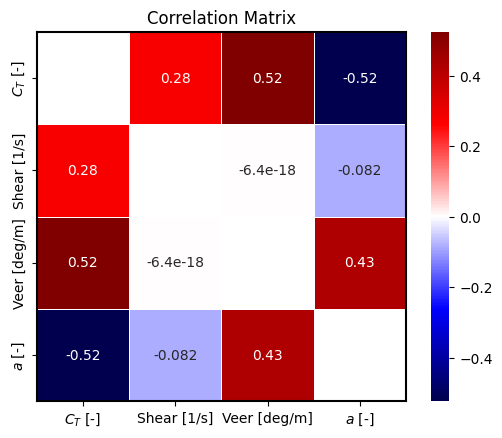


Plotting output vs each input:


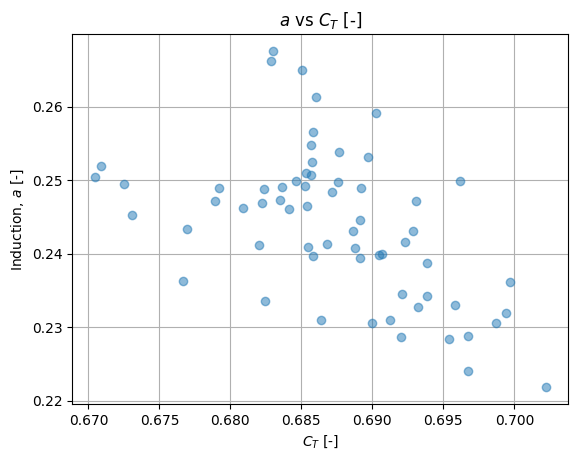

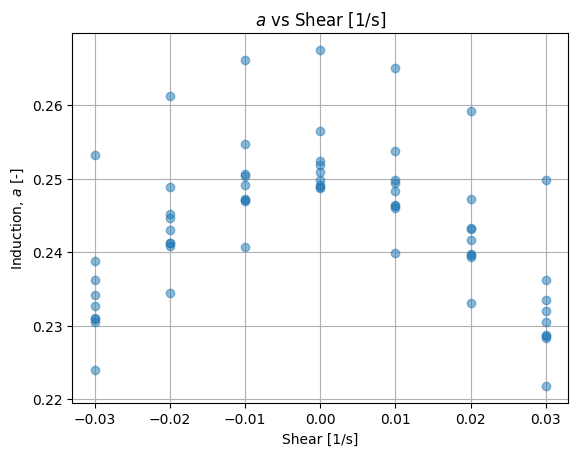

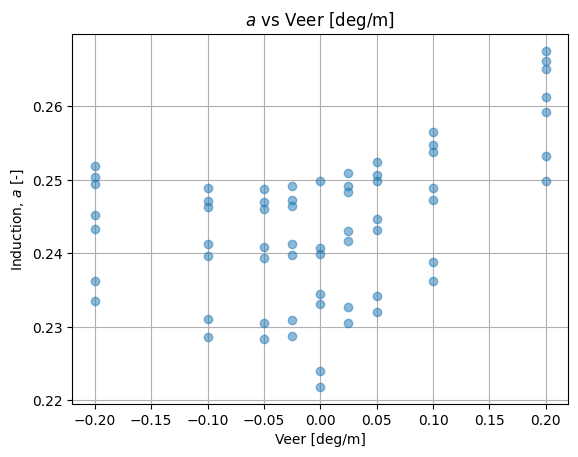

In [34]:
variable_names = ["$C_T$ [-]", "Shear [1/s]", "Veer [deg/m]"]

analyze_inputs(mat_10MW['X'], mat_10MW['y'].ravel(),variable_names)

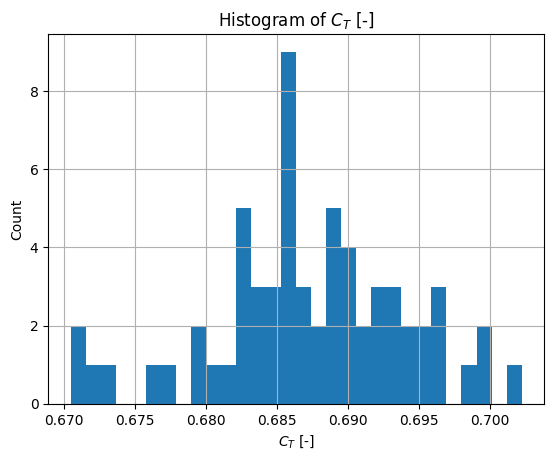

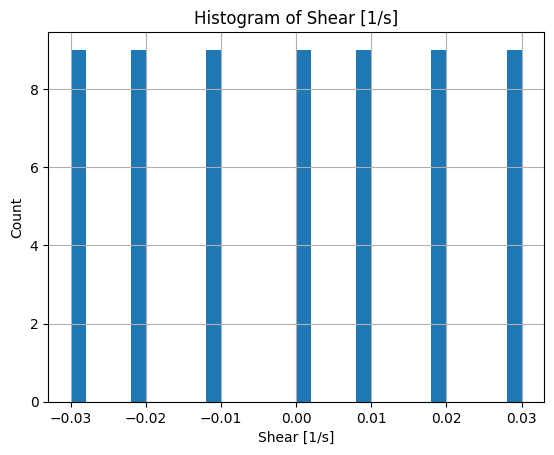

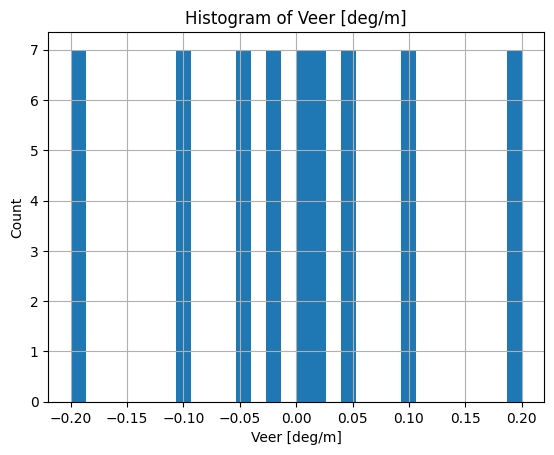

In [35]:
for i, name in enumerate(variable_names):
    plt.hist(mat_10MW['X'][:, i], bins=30)
    plt.title(f"Histogram of {name}")
    plt.xlabel(name)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

In [36]:
X_design = sm.add_constant(mat_10MW['X'])
vifs = [variance_inflation_factor(X_design, i + 1) for i in range(mat_10MW['X'].shape[1])]
for name, vif in zip(variable_names, vifs):
    print(f"VIF for {name}: {vif:.2f}")

VIF for $C_T$ [-]: 1.54
VIF for Shear [1/s]: 1.12
VIF for Veer [deg/m]: 1.42


/tmp/ipykernel_1714019/1907474693.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


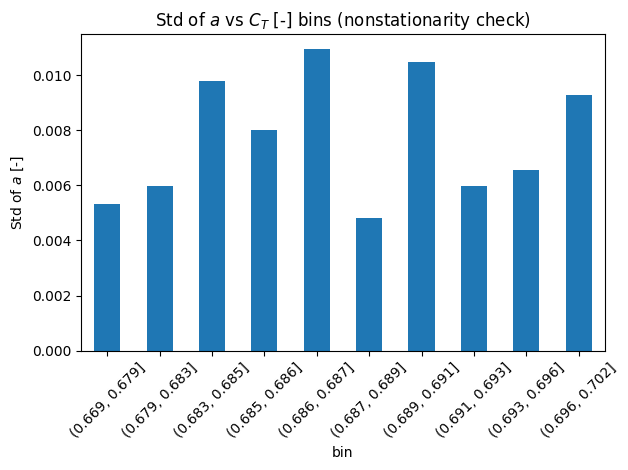

/tmp/ipykernel_1714019/1907474693.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


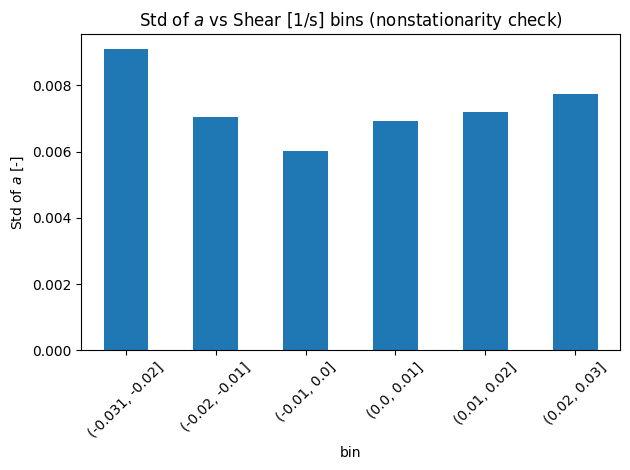

/tmp/ipykernel_1714019/1907474693.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


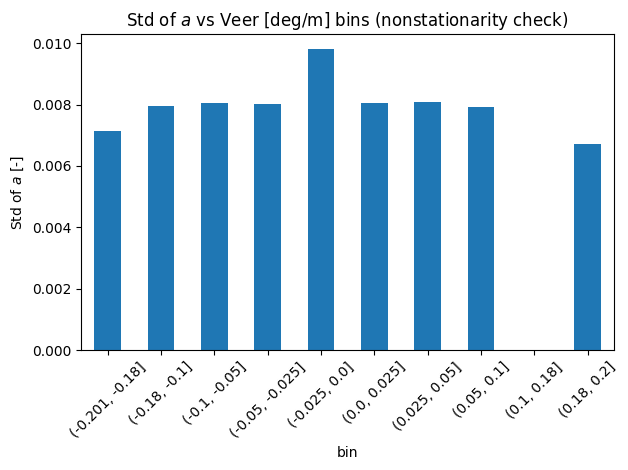

In [37]:
# Bin input and compute variance of y within each bin
for i, name in enumerate(variable_names):
    df = pd.DataFrame({name: mat_10MW['X'][:, i], 'y': mat_10MW['y'].ravel()})
    df['bin'] = pd.qcut(df[name], q=10, duplicates='drop')
    group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])
    group_stats.plot(y='std', kind='bar', legend=False)
    plt.title(f"Std of $a$ vs {name} bins (nonstationarity check)")
    plt.ylabel("Std of $a$ [-]")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 15MW Turbine

Basic statistics of input features:
$C_T$ [-]: mean=0.7471, std=0.0080, min=0.7267, max=0.7604
Shear [1/s]: mean=0.0000, std=0.0200, min=-0.0300, max=0.0300
Veer [deg/m]: mean=-0.0000, std=0.1087, min=-0.2000, max=0.2000

Correlation matrix (inputs + output):


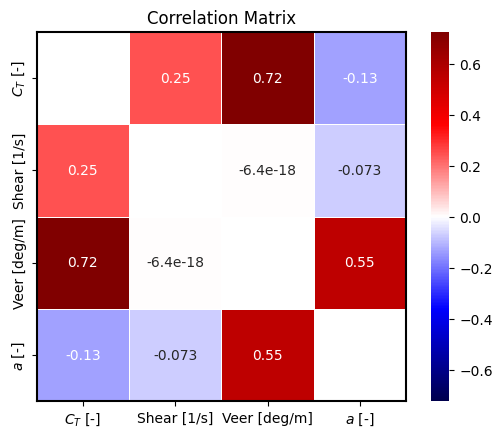


Plotting output vs each input:


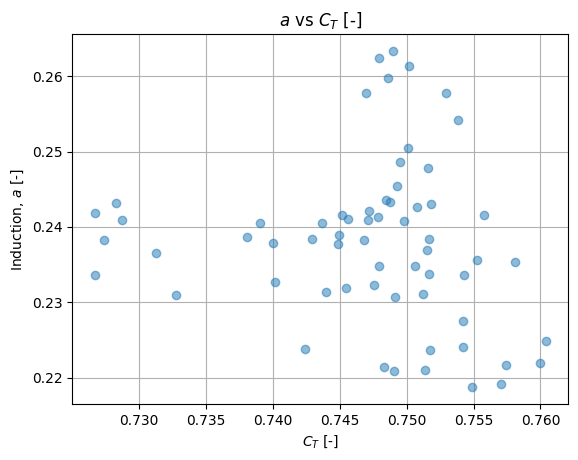

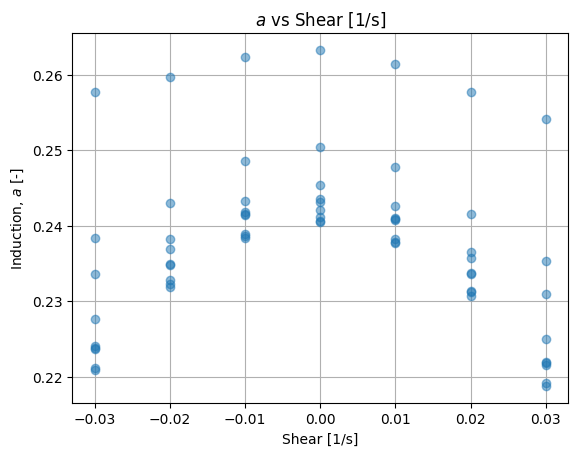

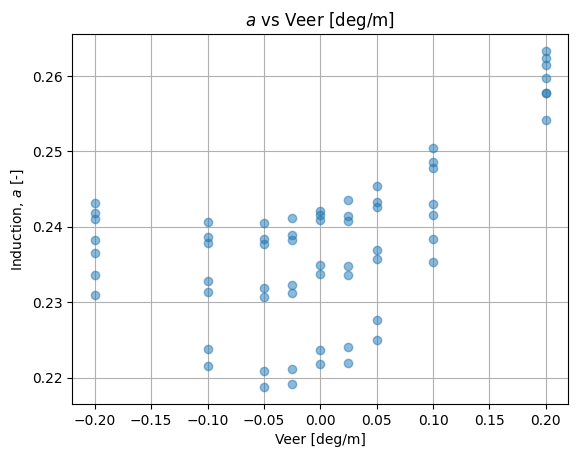

In [38]:
analyze_inputs(mat_15MW['X'], mat_15MW['y'].ravel(),variable_names)

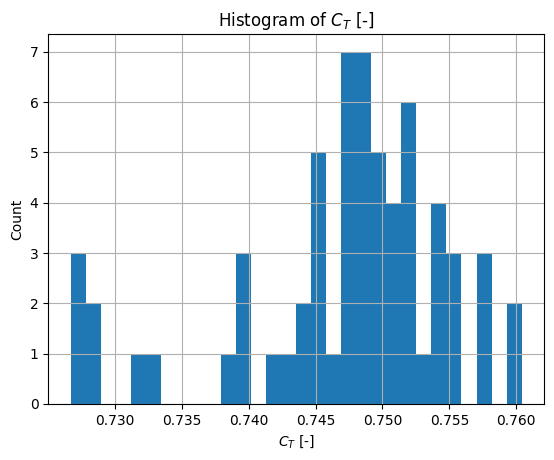

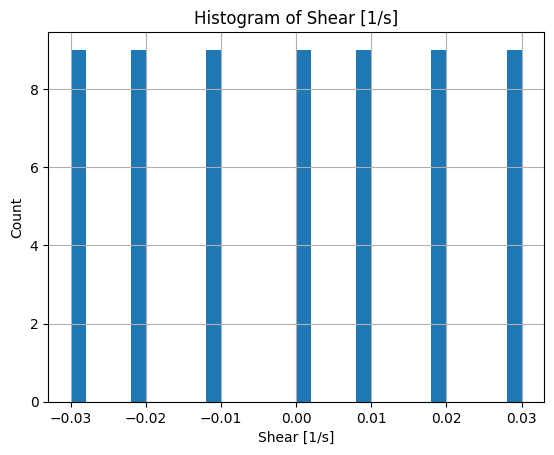

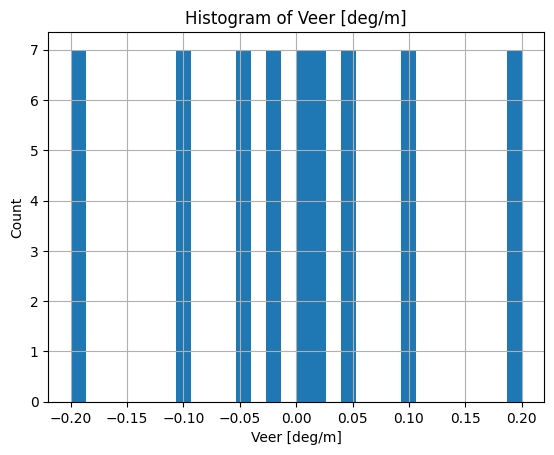

In [39]:
for i, name in enumerate(variable_names):
    plt.hist(mat_15MW['X'][:, i], bins=30)
    plt.title(f"Histogram of {name}")
    plt.xlabel(name)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

In [40]:
X_design = sm.add_constant(mat_15MW['X'])
vifs = [variance_inflation_factor(X_design, i + 1) for i in range(mat_15MW['X'].shape[1])]
for name, vif in zip(variable_names, vifs):
    print(f"VIF for {name}: {vif:.2f}")

VIF for $C_T$ [-]: 2.42
VIF for Shear [1/s]: 1.15
VIF for Veer [deg/m]: 2.27


/tmp/ipykernel_1714019/778330257.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


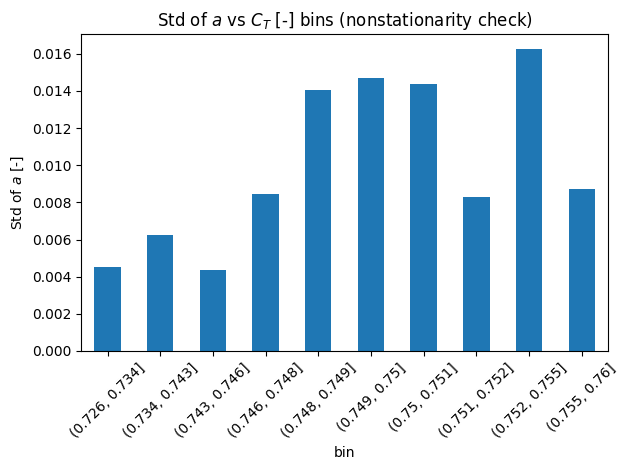

/tmp/ipykernel_1714019/778330257.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


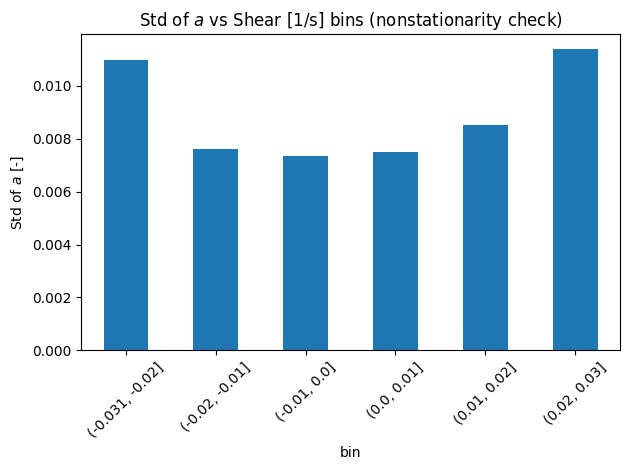

/tmp/ipykernel_1714019/778330257.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


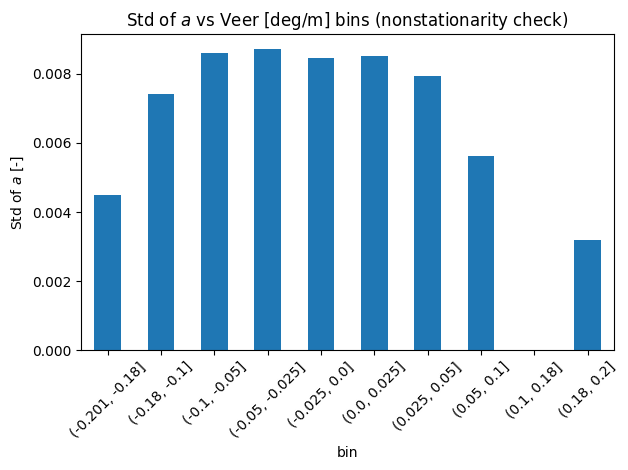

In [41]:
# Bin input and compute variance of y within each bin
for i, name in enumerate(variable_names):
    df = pd.DataFrame({name: mat_15MW['X'][:, i], 'y': mat_15MW['y'].ravel()})
    df['bin'] = pd.qcut(df[name], q=10, duplicates='drop')
    group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])
    group_stats.plot(y='std', kind='bar', legend=False)
    plt.title(f"Std of $a$ vs {name} bins (nonstationarity check)")
    plt.ylabel("Std of $a$ [-]")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# 22MW Turbine

Basic statistics of input features:
$C_T$ [-]: mean=0.7936, std=0.0142, min=0.7452, max=0.8128
Shear [1/s]: mean=0.0000, std=0.0200, min=-0.0300, max=0.0300
Veer [deg/m]: mean=-0.0000, std=0.1087, min=-0.2000, max=0.2000

Correlation matrix (inputs + output):


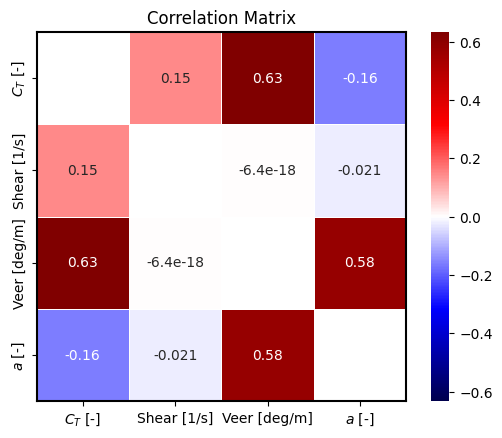


Plotting output vs each input:


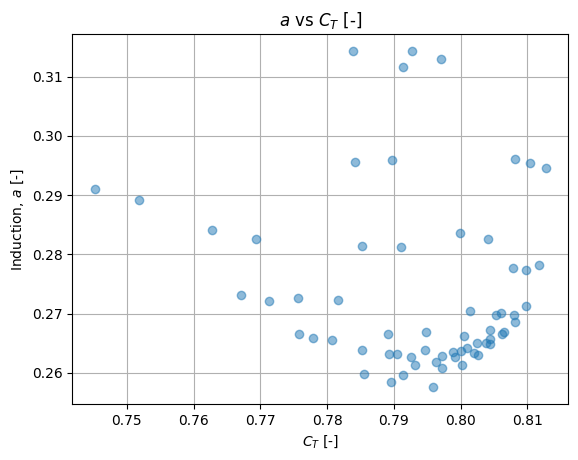

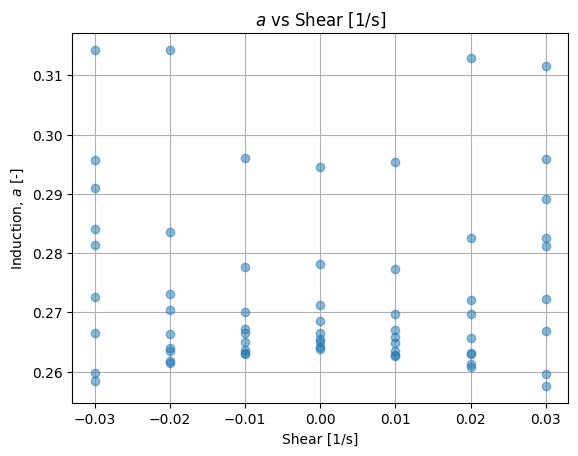

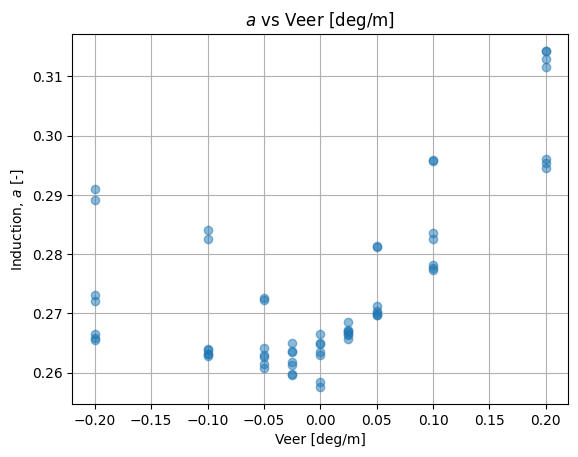

In [42]:
analyze_inputs(mat_22MW['X'], mat_22MW['y'].ravel(),variable_names)

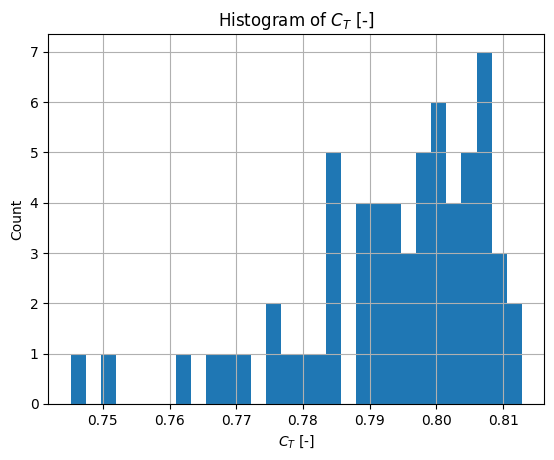

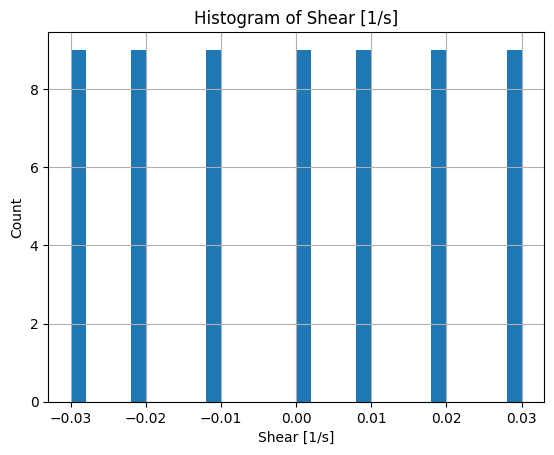

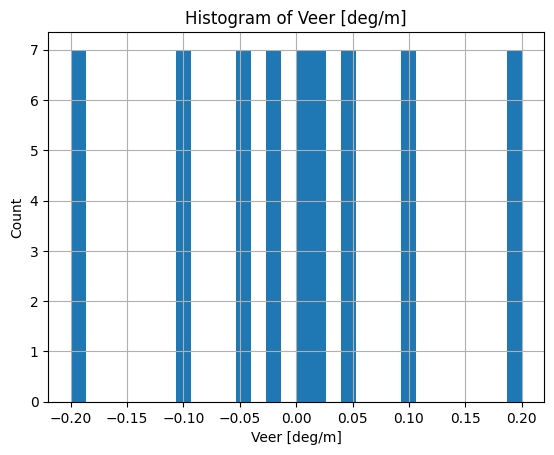

In [43]:
for i, name in enumerate(variable_names):
    plt.hist(mat_22MW['X'][:, i], bins=30)
    plt.title(f"Histogram of {name}")
    plt.xlabel(name)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

In [44]:
X_design = sm.add_constant(mat_22MW['X'])
vifs = [variance_inflation_factor(X_design, i + 1) for i in range(mat_22MW['X'].shape[1])]
for name, vif in zip(variable_names, vifs):
    print(f"VIF for {name}: {vif:.2f}")

VIF for $C_T$ [-]: 1.73
VIF for Shear [1/s]: 1.04
VIF for Veer [deg/m]: 1.69


/tmp/ipykernel_1714019/3251886510.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


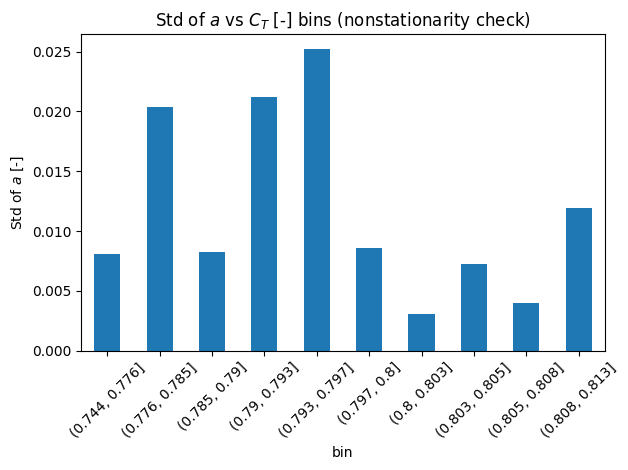

/tmp/ipykernel_1714019/3251886510.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


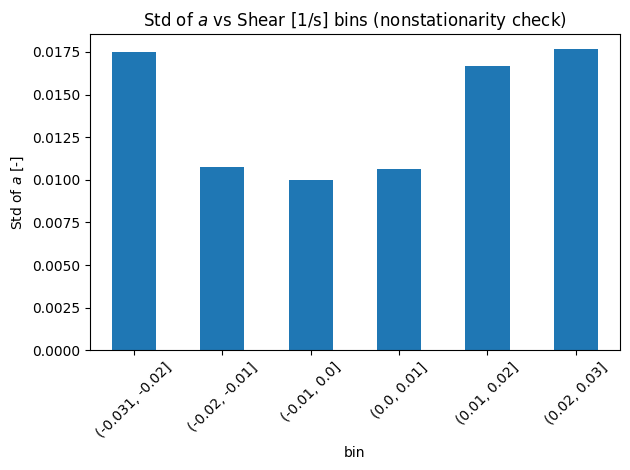

/tmp/ipykernel_1714019/3251886510.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


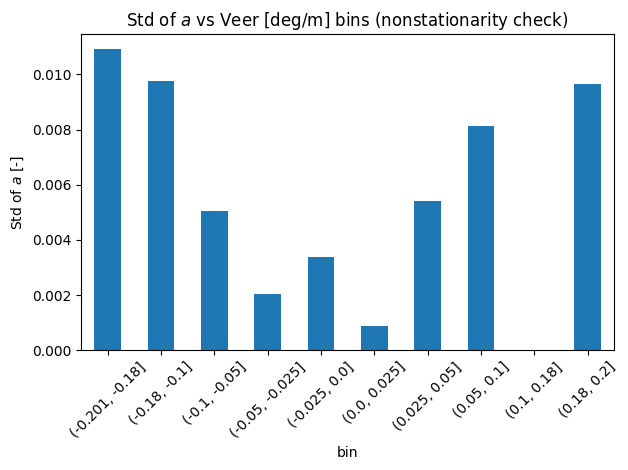

In [45]:
# Bin input and compute variance of y within each bin
for i, name in enumerate(variable_names):
    df = pd.DataFrame({name: mat_22MW['X'][:, i], 'y': mat_22MW['y'].ravel()})
    df['bin'] = pd.qcut(df[name], q=10, duplicates='drop')
    group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])
    group_stats.plot(y='std', kind='bar', legend=False)
    plt.title(f"Std of $a$ vs {name} bins (nonstationarity check)")
    plt.ylabel("Std of $a$ [-]")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# All turbines

Basic statistics of input features:
$C_T$ [-]: mean=0.7427, std=0.0447, min=0.6705, max=0.8128
Shear [1/s]: mean=0.0000, std=0.0200, min=-0.0300, max=0.0300
Veer [deg/m]: mean=0.0000, std=0.1087, min=-0.2000, max=0.2000

Correlation matrix (inputs + output):


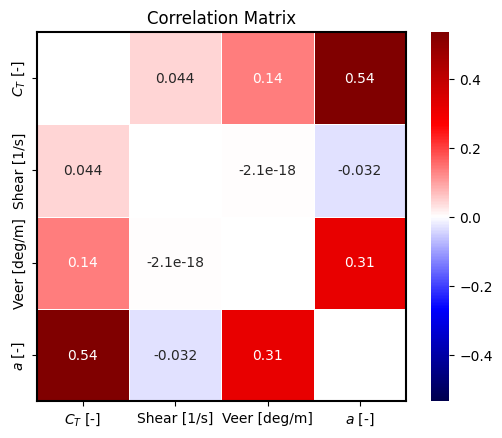


Plotting output vs each input:


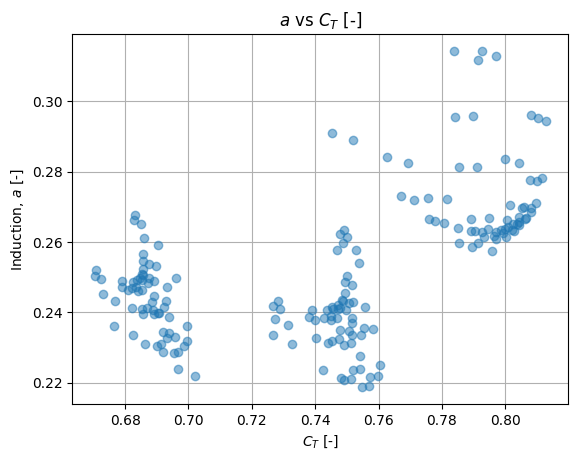

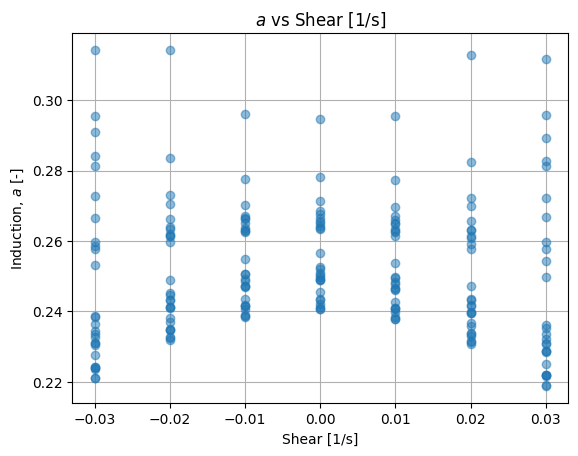

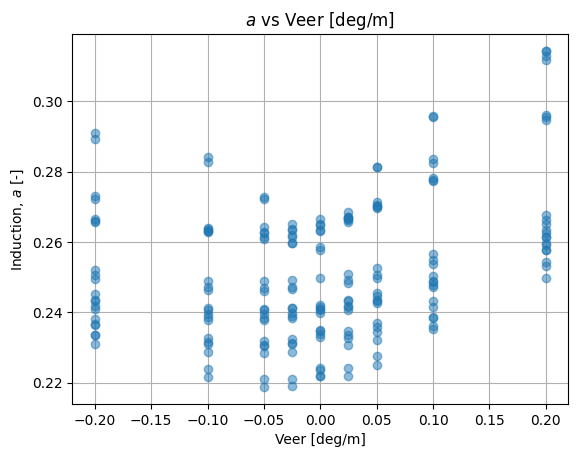

In [50]:
analyze_inputs(mat_ALL['X'], mat_ALL['y'].ravel(),variable_names)

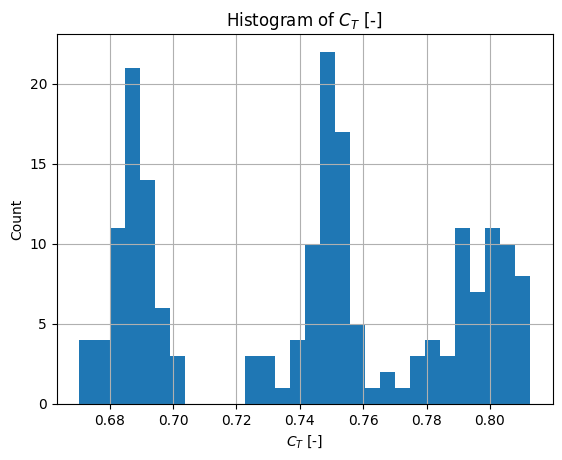

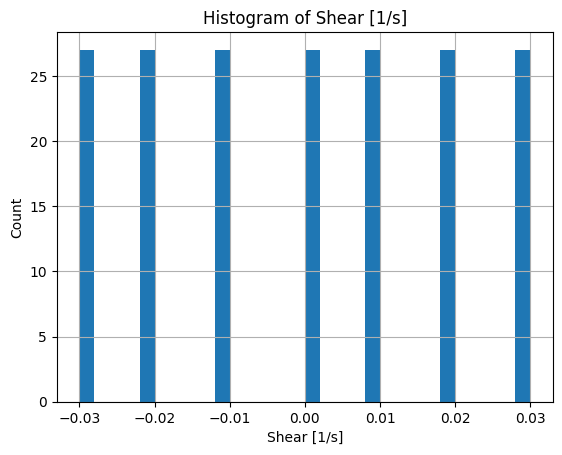

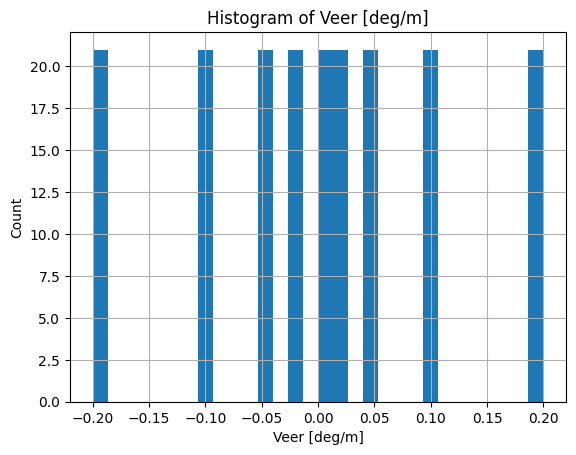

In [51]:
for i, name in enumerate(variable_names):
    plt.hist(mat_ALL['X'][:, i], bins=30)
    plt.title(f"Histogram of {name}")
    plt.xlabel(name)
    plt.ylabel("Count")
    plt.grid(True)
    plt.show()

In [52]:
X_design = sm.add_constant(mat_ALL['X'])
vifs = [variance_inflation_factor(X_design, i + 1) for i in range(mat_ALL['X'].shape[1])]
for name, vif in zip(variable_names, vifs):
    print(f"VIF for {name}: {vif:.2f}")

VIF for $C_T$ [-]: 1.02
VIF for Shear [1/s]: 1.00
VIF for Veer [deg/m]: 1.02


/tmp/ipykernel_1714019/1163778189.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


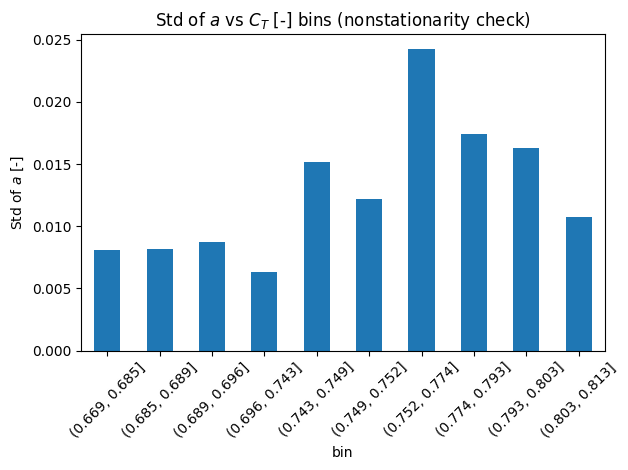

/tmp/ipykernel_1714019/1163778189.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


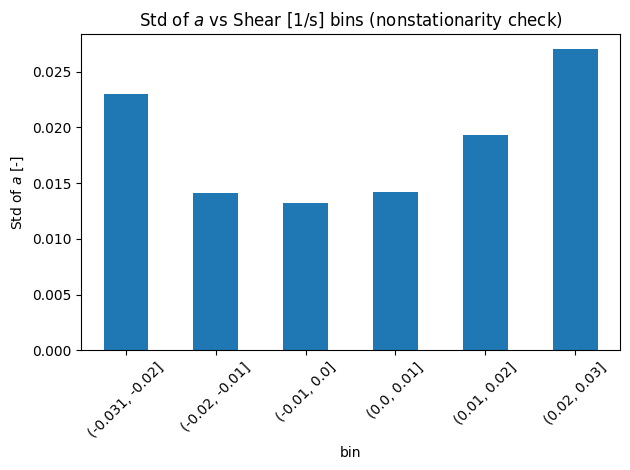

/tmp/ipykernel_1714019/1163778189.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])


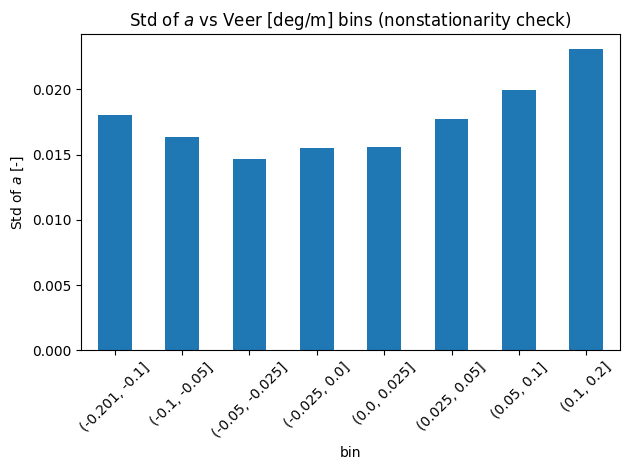

In [53]:
# Bin input and compute variance of y within each bin
for i, name in enumerate(variable_names):
    df = pd.DataFrame({name: mat_ALL['X'][:, i], 'y': mat_ALL['y'].ravel()})
    df['bin'] = pd.qcut(df[name], q=10, duplicates='drop')
    group_stats = df.groupby('bin')['y'].agg(['mean', 'std'])
    group_stats.plot(y='std', kind='bar', legend=False)
    plt.title(f"Std of $a$ vs {name} bins (nonstationarity check)")
    plt.ylabel("Std of $a$ [-]")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()